<a href="https://colab.research.google.com/github/avionerman/AML/blob/main/s2_food101_clip_blip_rag_with_claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Πως δουλευει αυτο το notebook

Φτιαχνουμε ενα συστημα **RAG** (Retrieval-Augmented Generation) για αυτοματη περιγραφη εικονων φαγητου. Τα τρια συστατικα του RAG:

### R — Retrieval με CLIP (OpenAI, 2021)
Vision-Language model. Κωδικοποιει εικονες και κειμενα στον ιδιο χωρο 512 διαστασεων, οποτε μπορουμε να μετραμε ομοιοτητα μεταξυ τους. Δινουμε εικονα-query και επιστρεφει τις K=5 πιο ομοιες απο τη συλλογη μας των 10.000 εικονων.

### A — Augmentation (δυο εναλλακτικες που συγκρινουμε)
Παιρνουμε τα labels των 5 retrieved εικονων και χτιζουμε ενα prompt prefix για το BLIP. Δοκιμαζουμε δυο μεθοδους:

- **vote** (baseline): επιλεγουμε το πιο συχνο label και φτιαχνουμε prompt `"a photo of {class}, which is"`. Απλο, deterministic, χωρις εξωτερικο API.
- **llm**: καλουμε το **Claude Haiku 4.5** (Anthropic, 2025) μεσω API. Του δινουμε τα 5 labels + scores και γραφει ενα context-aware prompt που αντικατοπτριζει αβεβαιοτητα οταν τα labels διαφωνουν.

### G — Generation με BLIP (Salesforce, 2022)
Image captioning model. Δεχεται **εικονα + prompt prefix** και **συμπληρωνει** την προταση βασει τι βλεπει στην εικονα.

Παραδειγμα:
- Input: εικονα πιτσας + prefix `"a photo of pizza, which is"`
- Output: `"a photo of pizza, which is on a white plate with mushrooms and cheese"`

Δηλαδη το BLIP δεν γραφει απο το μηδεν — του δινουμε ενα "ξεκινημα" (απο το augmentation) και αυτο το ολοκληρωνει βλεπωντας την εικονα. Χωρις prompt prefix, γραφει γενικολογα ("food on a plate"). Με καλο prompt prefix, γραφει συγκεκριμενα.

### Bonus — LoRA fine-tuning του BLIP (Microsoft, 2021)
Τεχνικη parameter-efficient fine-tuning. Αντι να επανεκπαιδευσουμε και τις 247M παραμετρους του BLIP, "παγωνουμε" τις αρχικες και προσθετουμε μικρους πινακες adapter (~590k νεες παραμετρους — μολις **0.24%** του μοντελου). Εκπαιδευουμε μονο αυτα τα adapters.

Παραδειγμα:
- Πριν: το BLIP γραφει γενικα `"food on a white plate"`
- Μετα απο LoRA σε ζευγαρια (εικονα, `"a photo of {κατηγορια}"`): το BLIP εχει μαθει τις 101 κατηγοριες και τις βαζει στις περιγραφες — `"tiramisu on a white plate"`

400x λιγοτερες παραμετρους προς εκπαιδευση, ~30 δευτερολεπτα εκπαιδευση αντι ωρων. Στη Φαση 9 συγκρινουμε BLIP με/χωρις LoRA σε ολες τις augmentation στρατηγικες.

### Η ροη του pipeline
```
εικονα → CLIP βρισκει 5 ομοιες → vote η Claude γραφει προταση → BLIP την συμπληρωνει
```

## Φαση 1 - Εγκατασταση

Εγκαθιστουμε ολες τις βιβλιοθηκες (transformers, torch, faiss, anthropic κλπ) σε μια εντολη. Παιρνει 1-2 λεπτα. Το `-q` σημαινει "σιωπηλα" - δεν δειχνει το log.

In [1]:
!pip install -q transformers datasets faiss-cpu accelerate peft "torchao>=0.16" anthropic torch torchvision Pillow tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.6/699.6 kB 59.6 MB/s eta 0:00:00


Φορτωνουμε ολες τις βιβλιοθηκες στη μνημη και ελεγχουμε αν εχουμε GPU (καρτα γραφικων). Με GPU ολα πανε ~10 φορες πιο γρηγορα. Στο Colab παμε σε Runtime → Change runtime type → T4 GPU.

In [2]:
import json, os, random, time
from collections import Counter
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor, BlipProcessor, BlipForConditionalGeneration
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
import faiss
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from anthropic import Anthropic

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


Ολες οι ρυθμισεις σε ενα σημειο. Αν θες να αλλαξεις κατι (πχ ποια εκδοση Claude η ποσες εικονες ανα κατηγορια), αλλαζεις εδω και πουθενα αλλου.

In [3]:
# All knobs in one place
CLIP_CKPT = "openai/clip-vit-base-patch32"
BLIP_CKPT = "Salesforce/blip-image-captioning-base"
CLAUDE_MODEL = "claude-haiku-4-5"
COLAB_SECRET_NAME = "dimi"

N_PER_CLASS_GALLERY = 100   # 100 classes * 100 = 10k gallery images
N_PER_CLASS_QUERY   = 10    # 100 classes * 10  = 1k queries
K = 5                       # top-k for retrieval
N_EVAL = 50                 # caption-proxy eval sample size

# LoRA (last phase)
LORA_R, LORA_ALPHA, LORA_DROPOUT = 8, 16, 0.05
LORA_EPOCHS = 1
LORA_TRAIN_SIZE = 2000

summary = {}

## Φαση 2 - Φορτωση των δεδομενων

Κατεβαζουμε το dataset Food-101 απο το HuggingFace (~5GB, παιρνει 3-5 λεπτα την πρωτη φορα). Το Food-101 εχει 101.000 εικονες απο 101 ειδη φαγητου.

Δεν τις χρειαζομαστε ολες - παιρνουμε **100 εικονες ανα κατηγορια** για το gallery (10.100 σuνολικα) και **10 ανα κατηγορια** για queries (1.010). Η `pick_balanced` φροντιζει να εχουμε ισο αριθμο απο καθε κατηγορια.

**Σημαντικο:** gallery και queries ειναι **διαφορετικα σετ** (απο train και validation splits) - δεν επικαλυπτονται.

In [4]:
ds = load_dataset("food101")
FOOD_CLASSES = ds["train"].features["label"].names
print(f"{len(FOOD_CLASSES)} classes — examples: {FOOD_CLASSES[:5]}")

rng = np.random.default_rng(SEED)

def pick_balanced(labels, n_per_class):
    out = []
    for c in range(len(FOOD_CLASSES)):
        cand = np.where(labels == c)[0]
        rng.shuffle(cand)
        out.extend(cand[:n_per_class].tolist())
    rng.shuffle(out)
    return out

gallery_idx = pick_balanced(np.array(ds["train"]["label"]), N_PER_CLASS_GALLERY)
query_idx   = pick_balanced(np.array(ds["validation"]["label"]), N_PER_CLASS_QUERY)
gallery_ds = ds["train"].select(gallery_idx)
query_ds   = ds["validation"].select(query_idx)
print(f"Gallery: {len(gallery_ds)}  Queries: {len(query_ds)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

101 classes — examples: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']
Gallery: 10100  Queries: 1010


Δειχνει τις 5 πρωτες εικονες του gallery για να βεβαιωθουμε οτι ολα φορτωθηκαν σωστα.

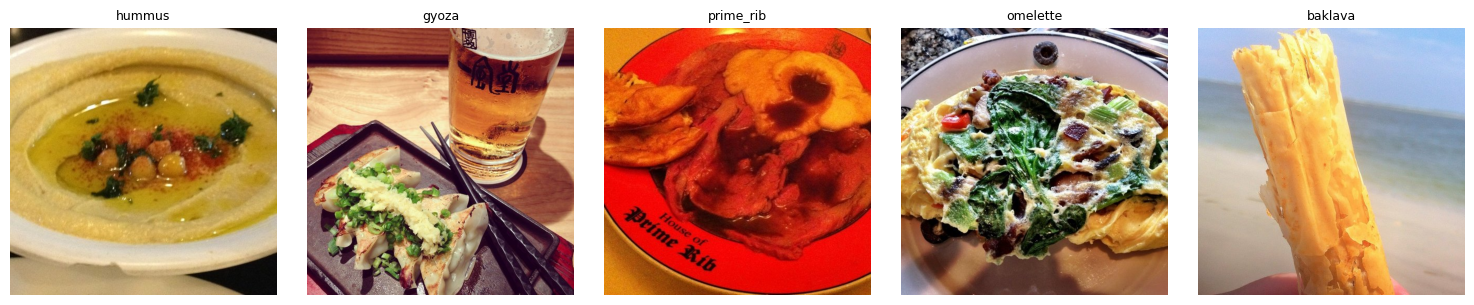

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, i in zip(axes, range(5)):
    s = gallery_ds[i]
    ax.imshow(s["image"]); ax.set_title(FOOD_CLASSES[s["label"]], fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## Φαση 3 - Φορτωση του CLIP

Κατεβαζουμε το CLIP απο το HuggingFace και το **παγωνουμε** (`requires_grad_(False)`). Δεν θα το εκπαιδευσουμε - θα το χρησιμοποιησουμε ως εχει.

In [6]:
clip_model = CLIPModel.from_pretrained(CLIP_CKPT).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_CKPT)
for p in clip_model.parameters():
    p.requires_grad_(False)
print(f"CLIP loaded — emb_dim={clip_model.config.projection_dim}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded — emb_dim=512


## Φαση 4 - Κωδικοποιηση του gallery + δημιουργια FAISS index

Δινουμε καθε εικονα στο CLIP, που τη μετατρεπει σε **512 αριθμους** (embedding) - σαν "δαχτυλικο αποτυπωμα". Αποθηκευουμε ολα τα embeddings σε **FAISS** βιβλιοθηκη που λειτουργει ως γρηγορο ευρετηριο - βρισκει τις πιο ομοιες σε χιλιοστοδευτερολεπτα.

Παιρνει ~30-60 δευτερολεπτα σε T4.

In [7]:
@torch.no_grad()
def clip_encode_images(pil_images, batch_size=64):
    out = []
    for i in tqdm(range(0, len(pil_images), batch_size), desc="CLIP encode"):
        batch = [img.convert("RGB") for img in pil_images[i:i + batch_size]]
        inp = clip_processor(images=batch, return_tensors="pt").to(device)
        vision_out = clip_model.vision_model(pixel_values=inp["pixel_values"])
        feats = clip_model.visual_projection(vision_out.pooler_output)
        e = F.normalize(feats, dim=-1)
        out.append(e.cpu())
    return torch.cat(out, 0)

gallery_images = [gallery_ds[i]["image"] for i in tqdm(range(len(gallery_ds)), desc="load gallery")]
gallery_labels = np.array([gallery_ds[i]["label"] for i in range(len(gallery_ds))])

t0 = time.time()
gallery_emb = clip_encode_images(gallery_images)
print(f"Encoded gallery in {time.time() - t0:.1f}s — shape {gallery_emb.shape}")

index = faiss.IndexFlatIP(gallery_emb.shape[1])
index.add(gallery_emb.numpy().astype(np.float32))
print(f"FAISS index size: {index.ntotal}")

load gallery:   0%|          | 0/10100 [00:00<?, ?it/s]

CLIP encode:   0%|          | 0/158 [00:00<?, ?it/s]

Encoded gallery in 36.5s — shape torch.Size([10100, 512])
FAISS index size: 10100


Δυο τροπους να ψαξουμε στη συλλογη:

- **`retrieve_by_image(εικονα)`** - δινουμε εικονα, μας επιστρεφει τις 5 πιο ομοιες
- **`retrieve_by_text("πιτσα")`** - δινουμε λεξη, μας επιστρεφει εικονες που μοιαζουν με πιτσα

Η `show_retrievals` τα δειχνει σε γραφημα - πανω αριστερα η εικονα-query, διπλα τα top-5 με score ομοιοτητας.

In [8]:
@torch.no_grad()
def retrieve_by_image(query_image, k=K):
    inp = clip_processor(images=[query_image.convert("RGB")], return_tensors="pt").to(device)
    vision_out = clip_model.vision_model(pixel_values=inp["pixel_values"])
    feats = clip_model.visual_projection(vision_out.pooler_output)
    q = F.normalize(feats, dim=-1).cpu().numpy().astype(np.float32)
    scores, ids = index.search(q, k)
    return scores[0], ids[0]

@torch.no_grad()
def retrieve_by_text(query_text, k=K):
    inp = clip_processor(text=[query_text], return_tensors="pt", padding=True).to(device)
    text_out = clip_model.text_model(
        input_ids=inp["input_ids"],
        attention_mask=inp.get("attention_mask"),
    )
    feats = clip_model.text_projection(text_out.pooler_output)
    q = F.normalize(feats, dim=-1).cpu().numpy().astype(np.float32)
    scores, ids = index.search(q, k)
    return scores[0], ids[0]

def show_retrievals(query, query_label=None, k=K):
    """`query` can be a PIL Image or a string."""
    if isinstance(query, str):
        scores, ids = retrieve_by_text(query, k)
        title_q, query_thumb = f'TEXT:\n"{query}"', None
    else:
        scores, ids = retrieve_by_image(query, k)
        title_q = "QUERY"
        if query_label is not None:
            title_q += f"\n({FOOD_CLASSES[query_label]})"
        query_thumb = query

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3))
    if query_thumb is not None:
        axes[0].imshow(query_thumb)
    else:
        axes[0].text(0.5, 0.5, query, ha="center", va="center", fontsize=10, wrap=True)
    axes[0].set_title(title_q, fontsize=9); axes[0].axis("off")
    for ax, s, i in zip(axes[1:], scores, ids):
        ax.imshow(gallery_images[i])
        ax.set_title(f"{FOOD_CLASSES[gallery_labels[i]]}\n{s:.3f}", fontsize=8); ax.axis("off")
    plt.tight_layout(); plt.show()
    return scores, ids

**Δοκιμη!** Πρωτα δινουμε 3 φωτογραφιες-queries και βλεπουμε ποιες ομοιες εικονες βρισκει το CLIP. Μετα δινουμε 3 κειμενα και βλεπουμε αν βρισκει σωστες εικονες.

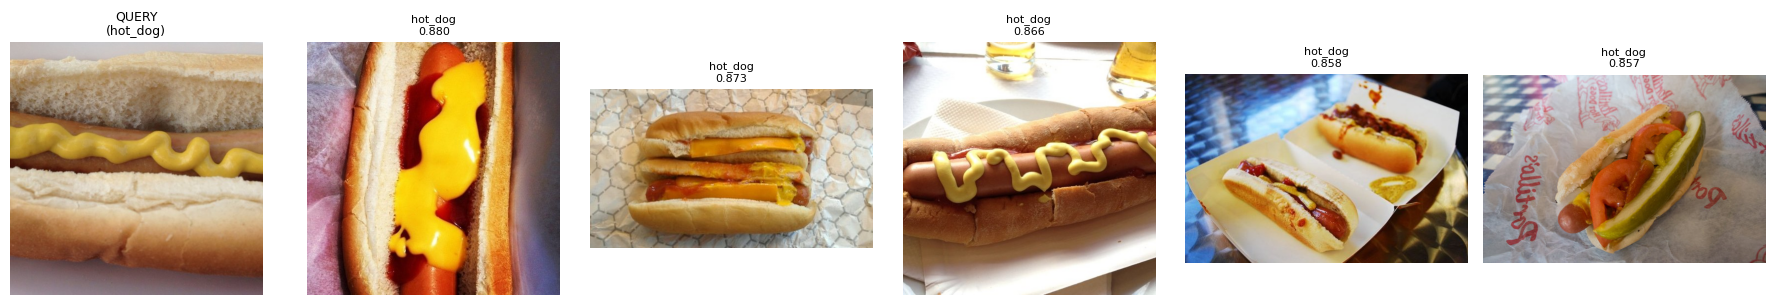

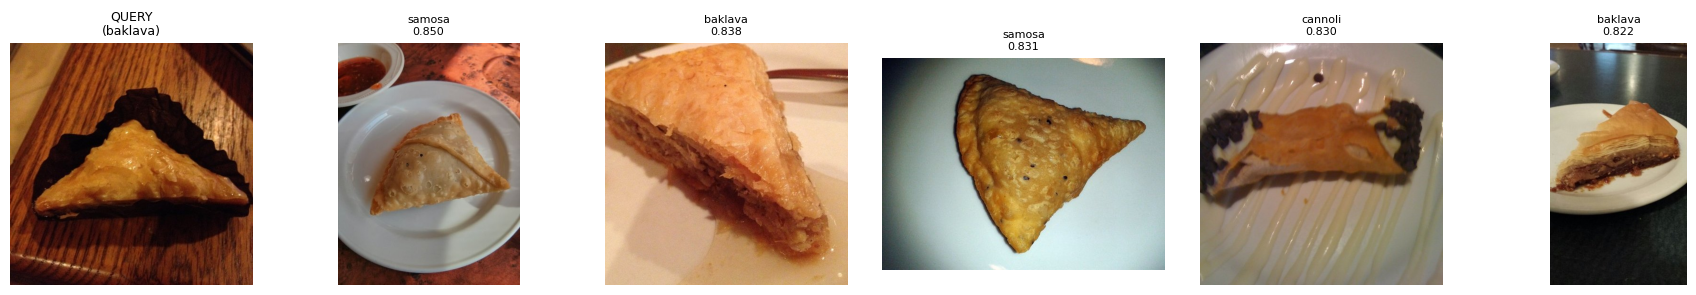

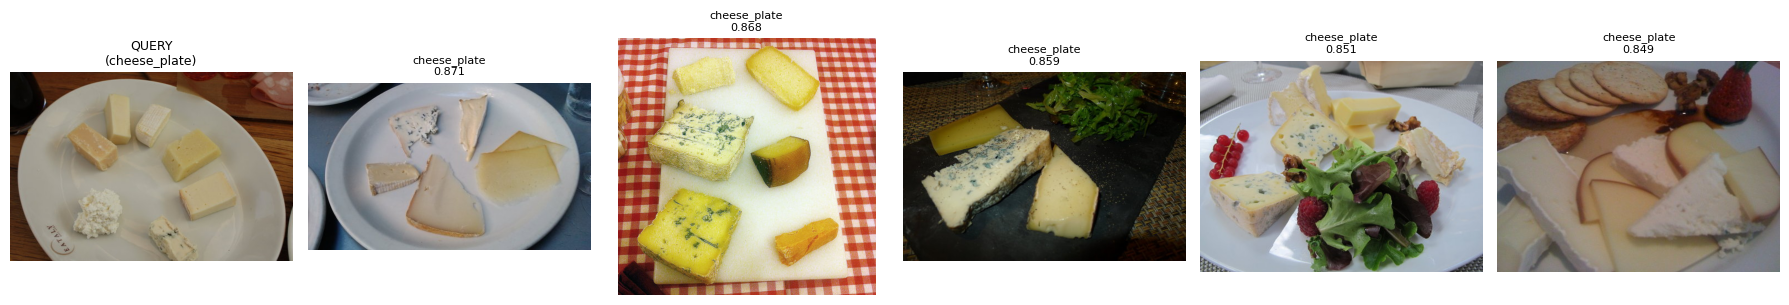

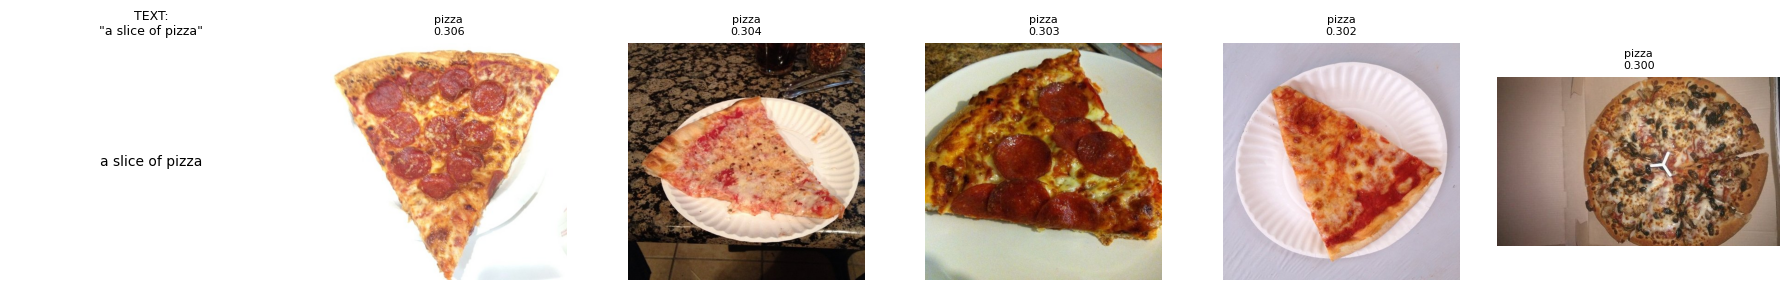

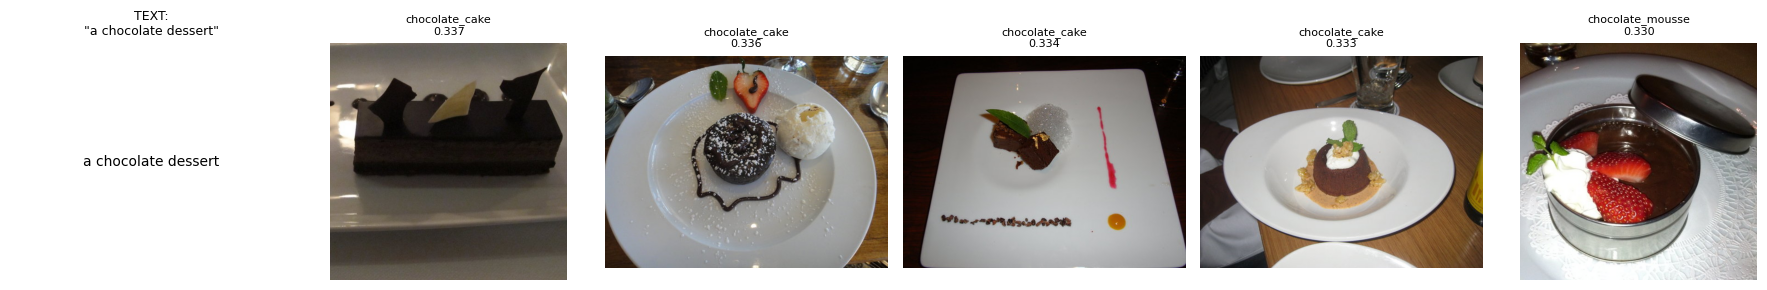

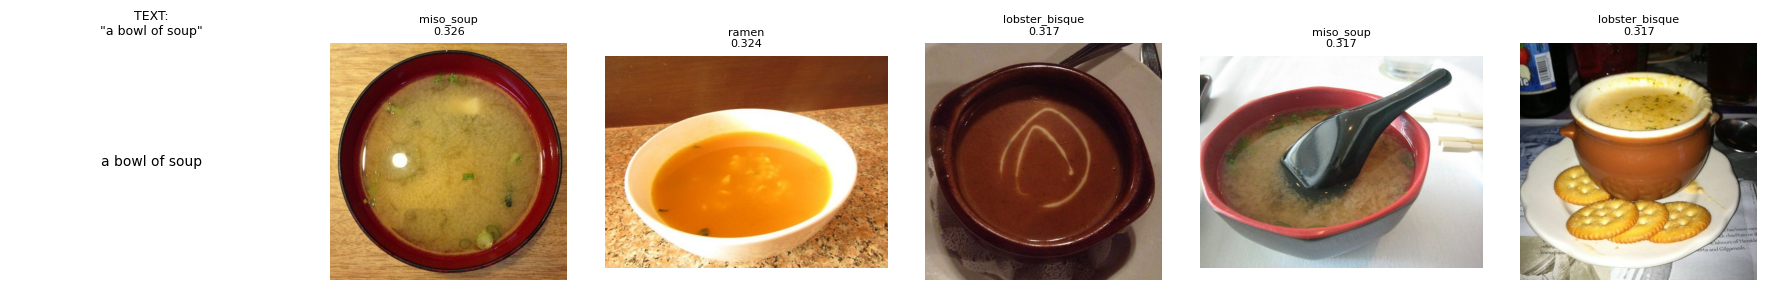

In [9]:
# Image queries
for i in [0, 5, 10]:
    q = query_ds[i]
    show_retrievals(q["image"], q["label"])

# Text queries — ask the RAG with words
for text in ["a slice of pizza", "a chocolate dessert", "a bowl of soup"]:
    show_retrievals(text)

## Φαση 5 - Μετραμε ποσο καλο ειναι το CLIP

**Recall@K** = ποσες φορες η σωστη κατηγορια εμφανιζεται στις πρωτες K θεσεις.

- Recall@1 = 0.76 σημαινει: στο 76% των queries, η πιο ομοια εικονα ειναι σωστης κατηγοριας
- Recall@5 = 0.91 σημαινει: στο 91%, η σωστη κατηγορια ειναι μεσα στις πρωτες 5

Τρεχει σε ολα τα 1010 queries. Παιρνει 30-60 δευτερολεπτα.

In [10]:
query_images = [query_ds[i]["image"] for i in tqdm(range(len(query_ds)), desc="load queries")]
query_labels = np.array([query_ds[i]["label"] for i in range(len(query_ds))])
query_emb = clip_encode_images(query_images)

def recall_at_k(qe, ql, gl, k):
    _, ids = index.search(qe.numpy().astype(np.float32), k)
    return float((gl[ids] == ql[:, None]).any(axis=1).mean())

retrieval_metrics = {f"Recall@{k}": recall_at_k(query_emb, query_labels, gallery_labels, k) for k in [1, 5, 10]}
print("Retrieval (frozen CLIP):")
for m, v in retrieval_metrics.items():
    print(f"  {m}: {v:.4f}")

load queries:   0%|          | 0/1010 [00:00<?, ?it/s]

CLIP encode:   0%|          | 0/16 [00:00<?, ?it/s]

Retrieval (frozen CLIP):
  Recall@1: 0.7614
  Recall@5: 0.9149
  Recall@10: 0.9584


## Φαση 6 - Φορτωση του BLIP

Κατεβαζουμε το BLIP (247 εκατομμυρια παραμετρους). Σχετικα μικρο - χωραει ανετα στη GPU.

In [11]:
blip_processor = BlipProcessor.from_pretrained(BLIP_CKPT)
blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_CKPT).to(device).eval()
print(f"BLIP loaded — {sum(p.numel() for p in blip_model.parameters()) / 1e6:.1f}M params")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP loaded — 247.4M params


## Φαση 6.5 - Φορτωση του Claude

Φορτωνουμε τον Claude (LLM της Anthropic) ως εναλλακτικη μεθοδο για το augmentation step του RAG.

**Setup:**
1. Παιρνουμε API key απο https://console.anthropic.com (κοστος ~4 σεντς για ολο το notebook)
2. Στο Colab → εικονιδιο κλειδι (αριστερα) → προσθετουμε secret με ονομα `dimi`

Η `llm_augment_prompt(labels, scores)` ζηταει απο τον Claude να γραψει το prompt prefix. Στο τελος κανουμε ενα μικρο test.

In [13]:
# Load API key from Colab Secrets (preferred) or env var
api_key = None
try:
    from google.colab import userdata
    api_key = userdata.get(COLAB_SECRET_NAME)
except (ImportError, Exception):
    api_key = os.environ.get("ANTHROPIC_API_KEY")

if not api_key:
    raise RuntimeError(
        f"No API key found. Add it as a Colab Secret named '{COLAB_SECRET_NAME}' "
        "(key icon in sidebar) or set the ANTHROPIC_API_KEY environment variable."
    )

anthropic_client = Anthropic(api_key=api_key)

def llm_augment_prompt(labels, scores):
    """Ask Claude Haiku to write a caption-prompt prefix from the top-k retrieved labels."""
    pairs = "\n".join(f"  - {lab} (similarity {s:.3f})" for lab, s in zip(labels, scores))
    msg = anthropic_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=80,
        messages=[{
            "role": "user",
            "content": (
                f"A CLIP retriever returned these top-{len(labels)} food guesses for an image:\n"
                f"{pairs}\n\n"
                "Write a short caption-prompt prefix (under 20 words, ending mid-sentence) that an "
                "image captioner will continue. Reflect the most likely dish; if the guesses agree, "
                "be confident; if they disagree, hedge naturally. Output ONLY the prefix text — no "
                "quotes, no explanation."
            ),
        }],
    )
    return msg.content[0].text.strip()

# Quick test — make sure the API call works
demo_labels = ["tiramisu", "cheesecake", "tiramisu", "panna_cotta", "tiramisu"]
demo_scores = [0.91, 0.88, 0.85, 0.82, 0.79]
print("Test prompt from Claude Haiku:")
print(f"  {llm_augment_prompt(demo_labels, demo_scores)}")

Test prompt from Claude Haiku:
  This creamy Italian dessert with delicate layers of


## Φαση 7 - Το RAG σε δραση

Η κεντρικη συναρτηση `caption()`. Δεχεται μια εικονα και τον τροπο που θες να δουλεψει:

- **`augment_mode='none'`** - μονο το BLIP, χωρις βοηθεια απο CLIP/Claude
- **`augment_mode='vote'`** - απλη ψηφοφορια (το πιο συχνο label απο τα 5 του CLIP)
- **`augment_mode='llm'`** - ο Claude γραφει εξυπνη προταση

Το demo στο τελος συγκρινει τους 3 τροπους σε 3 εικονες.

In [14]:
@torch.no_grad()
def caption(query_image, augment_mode="vote", k=K, max_new_tokens=40):
    """augment_mode: 'none' | 'vote' | 'llm'"""
    prompt = ""
    if augment_mode in {"vote", "llm"}:
        scores, ids = retrieve_by_image(query_image, k)
        labels = [FOOD_CLASSES[gallery_labels[i]].replace("_", " ") for i in ids]
        if augment_mode == "vote":
            top = Counter(labels).most_common(1)[0][0]
            prompt = f"a photo of {top}, which is"
        else:  # llm
            prompt = llm_augment_prompt(labels, scores.tolist())

    inp = blip_processor(
        images=query_image.convert("RGB"),
        text=prompt or None,
        return_tensors="pt",
    ).to(device)
    out = blip_model.generate(**inp, max_new_tokens=max_new_tokens, num_beams=4, repetition_penalty=1.1)
    return blip_processor.decode(out[0], skip_special_tokens=True)

# Demo: all three modes on the same query
for i in [0, 50, 200]:
    q = query_ds[i]
    print(f"\n--- True class: {FOOD_CLASSES[q['label']]}")
    print(f"  None (no RAG):  {caption(q['image'], augment_mode='none')}")
    print(f"  Vote augmenter: {caption(q['image'], augment_mode='vote')}")
    print(f"  LLM augmenter:  {caption(q['image'], augment_mode='llm')}")


--- True class: hot_dog
  None (no RAG):  a hot dog with mustard on a white plate
  Vote augmenter: a photo of hot dog, which is served on a white plate
  LLM augmenter:  this appetizing image shows a delicious hot dog with mustard sauce

--- True class: falafel
  None (no RAG):  food on a blue plate
  Vote augmenter: a photo of falafel, which is on a blue plate
  LLM augmenter:  this golden, crispy round food appears to be eaten

--- True class: beignets
  None (no RAG):  a plate of food with powder and powder
  Vote augmenter: a photo of beignets, which is part of the desserts offered at the restaurant
  LLM augmenter:  this image shows a plate of freshly fried beignets, those delicious square - shaped pastries that are covered with powder and powdered sugar


## Φαση 8 - Μετραμε ποιος τροπος ειναι καλυτερος

Το Food-101 δεν εχει ετοιμες περιγραφες, αρα δεν μπορουμε να μετρησουμε αν η περιγραφη ειναι "καλη". Αντι γι'αυτο: **η περιγραφη του BLIP περιεχει τη σωστη λεξη;**

Πχ αν η σωστη απαντηση ειναι "πιτσα", η περιγραφη του BLIP λεει "πιτσα";

Τρεχει 50 εικονες x 3 τροπους = 150 περιγραφες. Παιρνει 1-2 λεπτα.

In [15]:
def caption_mentions_class(text, class_id):
    return FOOD_CLASSES[class_id].replace("_", " ").lower() in text.lower()

sample_idx = np.random.default_rng(0).choice(len(query_ds), size=N_EVAL, replace=False)

modes = ["none", "vote", "llm"]
hits = {m: 0 for m in modes}
t0 = time.time()
for i in tqdm(sample_idx, desc="captioning"):
    q = query_ds[int(i)]
    for m in modes:
        if caption_mentions_class(caption(q["image"], augment_mode=m), q["label"]):
            hits[m] += 1

caption_results = {
    "n": N_EVAL,
    "no_rag_class_hit":   hits["none"] / N_EVAL,
    "rag_vote_class_hit": hits["vote"] / N_EVAL,
    "rag_llm_class_hit":  hits["llm"]  / N_EVAL,
    "seconds": time.time() - t0,
}
print(json.dumps(caption_results, indent=2))

captioning:   0%|          | 0/50 [00:00<?, ?it/s]

{
  "n": 50,
  "no_rag_class_hit": 0.1,
  "rag_vote_class_hit": 0.84,
  "rag_llm_class_hit": 0.58,
  "seconds": 95.19786429405212
}


## Φαση 9 - Εκπαιδευση LoRA (προαιρετικο)

Εκπαιδευουμε ενα μικρο LoRA adapter πανω στο BLIP σε 2000 ζευγαρια (εικονα, "a photo of {κατηγορια}").

Προαιρετικο - αν δεν θες να περιμενεις, παρελειψε αυτη τη φαση. Παιρνει ~30 δευτερολεπτα σε T4.

In [16]:
def make_caption(class_id):
    return f"a photo of {FOOD_CLASSES[class_id].replace('_', ' ')}"

perm = np.random.default_rng(1).permutation(len(gallery_images))
caption_train_idx = perm[:LORA_TRAIN_SIZE]

class CaptionPairs(Dataset):
    def __init__(self, idx): self.idx = idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        k = int(self.idx[i])
        return gallery_images[k], make_caption(int(gallery_labels[k]))

def collate(batch):
    imgs, caps = zip(*batch)
    inp = blip_processor(images=list(imgs), text=list(caps), padding=True, return_tensors="pt")
    inp["labels"] = inp["input_ids"].clone()
    return inp

caption_train_loader = DataLoader(CaptionPairs(caption_train_idx), batch_size=8, shuffle=True, collate_fn=collate)
print(f"Train batches: {len(caption_train_loader)}")

Train batches: 250


**Βιδωνουμε το LoRA στο BLIP.** Μονο **590.000 παραμετροι** θα εκπαιδευτουν αντι για 247 εκατομμυρια. Πολυ πιο γρηγορο και φθηνο σε μνημη.

In [17]:
# Attach LoRA to the SAME blip_model (no second copy in VRAM)
lora_cfg = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=["query", "value"], bias="none",
)
blip_model = get_peft_model(blip_model, lora_cfg)
blip_model.print_trainable_parameters()

trainable params: 589,824 || all params: 248,034,424 || trainable%: 0.2378


**Η εκπαιδευση.** 1 epoch x 250 batches. Με καλη GPU (T4 η L4) παιρνει 1-2 λεπτα. Στο τελος αποθηκευει το adapter στο `blip_food_lora/`.

In [18]:
opt = torch.optim.AdamW(blip_model.parameters(), lr=5e-5, weight_decay=1e-4)

blip_model.train()
t0 = time.time()
for ep in range(LORA_EPOCHS):
    losses = []
    pb = tqdm(caption_train_loader, desc=f"epoch {ep + 1}")
    for batch in pb:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = blip_model(**batch).loss
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        pb.set_postfix(loss=f"{np.mean(losses[-50:]):.4f}")
print(f"Fine-tuning took {time.time() - t0:.1f}s")
blip_model.save_pretrained("blip_food_lora")
blip_model.eval()
print("Saved LoRA adapter to blip_food_lora/")

epoch 1:   0%|          | 0/250 [00:00<?, ?it/s]

Fine-tuning took 56.3s
Saved LoRA adapter to blip_food_lora/


**Συγκριση 6 περιπτωσεων:** 3 τροποι (none/vote/llm) x 2 BLIPs (απλο / με LoRA). Τρεχει 6 x 50 = 300 περιγραφες. Παιρνει 2-3 λεπτα.

In [19]:
# Compare base (adapter OFF) vs LoRA (adapter ON) across all three augment modes
def eval_hits(mode, with_lora):
    ctx = nullcontext() if with_lora else blip_model.disable_adapter()
    h = 0
    with ctx:
        for i in sample_idx:
            q = query_ds[int(i)]
            if caption_mentions_class(caption(q["image"], augment_mode=mode), q["label"]):
                h += 1
    return h / N_EVAL

summary = {}
for with_lora in [False, True]:
    for mode in ["none", "vote", "llm"]:
        key = f"{'lora' if with_lora else 'base'}_{mode}"
        summary[key] = eval_hits(mode, with_lora)

print(json.dumps(summary, indent=2))

{
  "base_none": 0.1,
  "base_vote": 0.84,
  "base_llm": 0.62,
  "lora_none": 0.46,
  "lora_vote": 0.84,
  "lora_llm": 0.5
}


## Φαση 10 - Demo απο ολο το pipeline

Για 3 εικονες και 1 κειμενο, βλεπουμε ολη τη δουλεια του pipeline σε δραση: top-5 ομοιες εικονες + 3 διαφορετικες περιγραφες (none/vote/llm).

Καντε screenshots αυτων - ειναι το πιο εντυπωσιακο κομματι για την παρουσιαση.

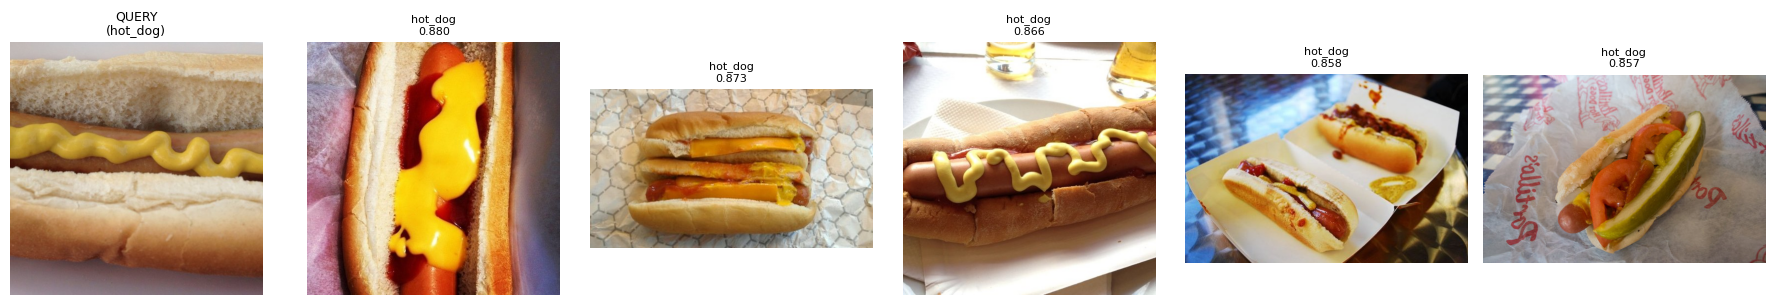

Caption (no RAG):     a photo of hot dog
Caption (vote RAG):   a photo of hot dog, which is one of the most popular food in the united states
Caption (LLM RAG):    this appetizing hot dog features mustard


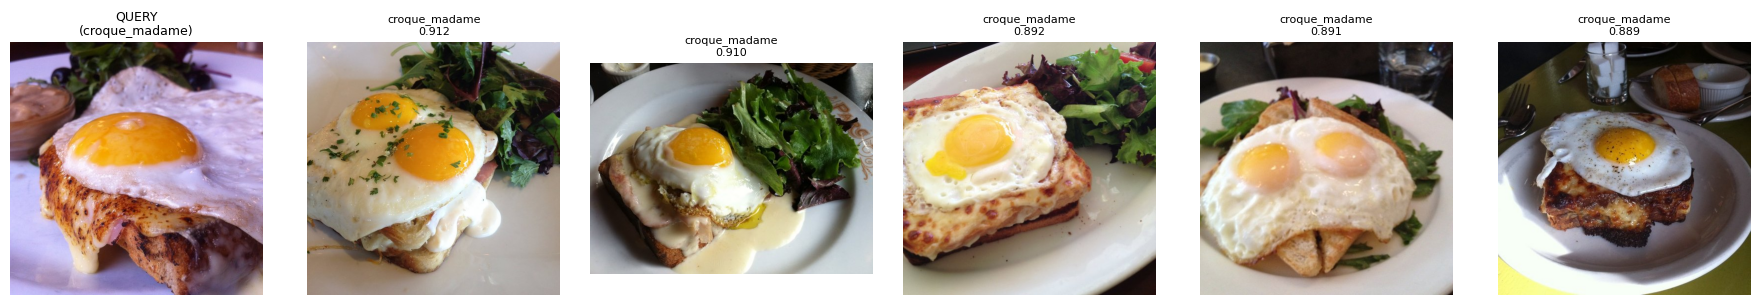

Caption (no RAG):     a photo of grilled egg sandwich
Caption (vote RAG):   a photo of croque madame, which is a photo of croque madame
Caption (LLM RAG):    this is a delicious croque madame, a classic french sandwich featuring a fried egg


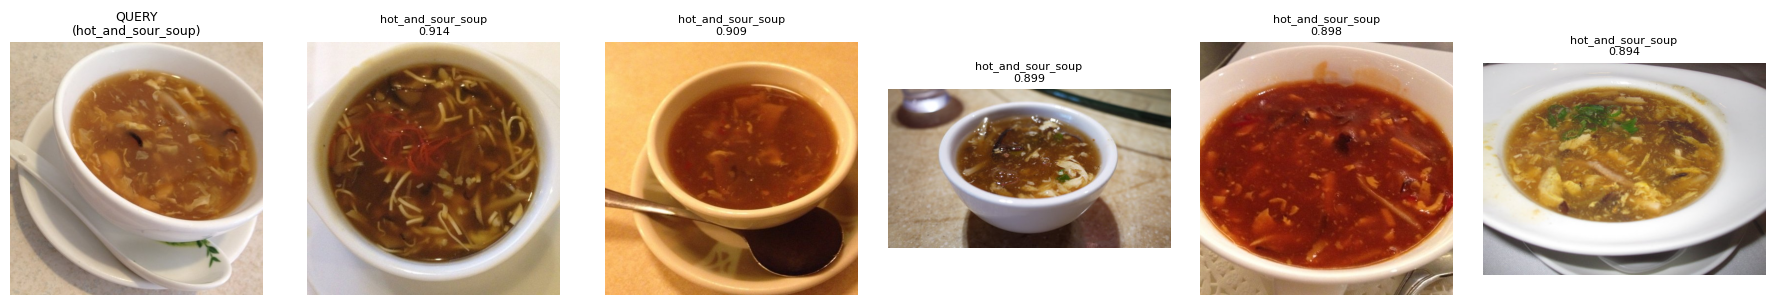

Caption (no RAG):     a photo of soup
Caption (vote RAG):   a photo of hot and sour soup, which is one of the best soups
Caption (LLM RAG):    this is a steaming bowl of hot and sour soup, featuring a picture of a photo of hot and sour soup


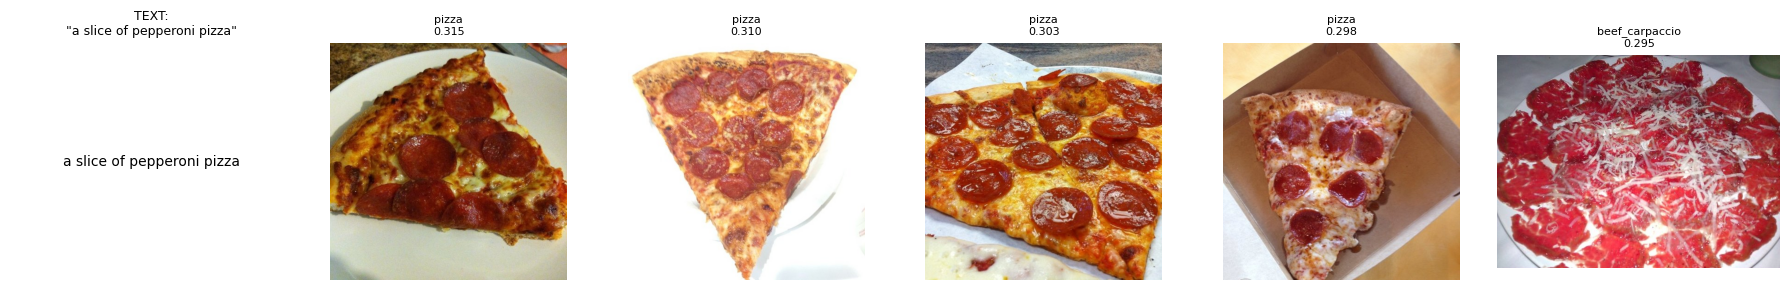

Caption (no RAG):     a photo of pepperonie pizza
Caption (vote RAG):   a photo of pizza, which is a photo of a slice of pizza
Caption (LLM RAG):    a delicious pizza with pepperonie


In [20]:
def full_demo(query, query_label=None, k=K):
    show_retrievals(query, query_label, k)
    if isinstance(query, str):
        # Text query → caption the top-1 retrieved image
        _, ids = retrieve_by_text(query, k)
        img = gallery_images[ids[0]]
    else:
        img = query
    print(f"Caption (no RAG):     {caption(img, augment_mode='none')}")
    print(f"Caption (vote RAG):   {caption(img, augment_mode='vote', k=k)}")
    print(f"Caption (LLM RAG):    {caption(img, augment_mode='llm',  k=k)}")

# Image-driven demos
for i in [0, 100, 500]:
    q = query_ds[i]
    print("=" * 80)
    full_demo(q["image"], q["label"])

# Text-driven demo
print("=" * 80)
full_demo("a slice of pepperoni pizza")

## Φαση 11 - Αποθηκευση αποτελεσματων

Σωζει ολα τα νουμερα σε `s2_results.json` (Recall@k, Phase 8 results, Phase 9 LoRA comparison, config). Αυτο το αρχειο θα το βαλεις στο report.

In [21]:
results = {
    "retrieval": retrieval_metrics,
    "caption_proxy": caption_results,
    "lora_comparison": summary,
    "config": {
        "clip_ckpt": CLIP_CKPT,
        "blip_ckpt": BLIP_CKPT,
        "claude_model": CLAUDE_MODEL,
        "n_gallery": len(gallery_images),
        "n_query": len(query_images),
        "k": K,
    },
}
with open("s2_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "retrieval": {
    "Recall@1": 0.7613861386138614,
    "Recall@5": 0.9148514851485149,
    "Recall@10": 0.9584158415841584
  },
  "caption_proxy": {
    "n": 50,
    "no_rag_class_hit": 0.1,
    "rag_vote_class_hit": 0.84,
    "rag_llm_class_hit": 0.58,
    "seconds": 95.19786429405212
  },
  "lora_comparison": {
    "base_none": 0.1,
    "base_vote": 0.84,
    "base_llm": 0.62,
    "lora_none": 0.46,
    "lora_vote": 0.84,
    "lora_llm": 0.5
  },
  "config": {
    "clip_ckpt": "openai/clip-vit-base-patch32",
    "blip_ckpt": "Salesforce/blip-image-captioning-base",
    "claude_model": "claude-haiku-4-5",
    "n_gallery": 10100,
    "n_query": 1010,
    "k": 5
  }
}


## Summary

1. **Προβλημα**: zero-shot VLM captioning σε fine-grained φαγητο ειναι αναξιοπιστο → augment με retrieval step που εντοπιζει την κατηγορια → conditioning του caption σε αυτο.
2. **Μεθοδολογια**: CLIP retriever + FAISS + BLIP generator, με ΔΥΟ augmenters σε συγκριση (vote vs Claude LLM) και προαιρετικο LoRA fine-tune.
3. **Μοντελα**:
   - CLIP image encoder = ViT
   - CLIP text encoder = GPT-2-style text Transformer
   - BLIP = ViT encoder + text-decoder Transformer
   - Claude Haiku 4.5 (Anthropic API) = ο smart augmenter
4. **Αποτελεσματα**: Recall@{1,5,10} για retrieval; class-name coverage για none/vote/llm; ιδια συγκριση με LoRA on/off.